In [1]:
# ============================================================
# Task 2 — Feature Engineering & Preprocessing
# ============================================================

import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../")

from src.preprocessing import *

sns.set_style("whitegrid")


# ============================================================
# Section 1 — Load Cleaned Dataset
# ============================================================
df = load_clean_data("../data/processed/telco_cleaned.csv")
print(df.shape)
display(df.head())


# ============================================================
# Section 2 — Drop Identifier + Encode Target
# ============================================================
df = drop_identifier(df)
df = encode_targets(df)


# ============================================================
# Section 3 — Create Derived Features
# ============================================================
df = create_derived_features(df)
display(df.head())


# ============================================================
# Section 4 — Encoding
# ============================================================
df = label_encode_binary(df)
df = one_hot_encode(df)

print(df.shape)


# ============================================================
# Section 5 — Feature Scaling Comparison
# ============================================================
df_std, std_scaler = scale_features(df.copy(), method="standard")
df_mm, mm_scaler = scale_features(df.copy(), method="minmax")

display(df_std.head())
display(df_mm.head())


# ============================================================
# Section 6 — Feature Selection
# ============================================================
X = df_std.drop(columns=["churn"])
y = df_std["churn"]

drop_cols = correlation_filter(X)
print("Highly correlated columns:", drop_cols)

selected_rfe = rfe_selection(X, y)
print("RFE Selected Features:", selected_rfe)

print("Tree Feature Importance:")
display(tree_feature_importance(X, y))

print("Mutual Information:")
display(mutual_info_selection(X, y))


# ============================================================
# Section 7 — Handle Class Imbalance
# ============================================================
X_smote, y_smote = apply_smote(X, y)
print("After SMOTE:", pd.Series(y_smote).value_counts())

X_under, y_under = apply_random_undersampling(X, y)
print("After Undersampling:", pd.Series(y_under).value_counts())

print("Class Weights:", get_class_weights(y))


# ============================================================
# Section 8 — Train / Validation / Test Split
# ============================================================
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y, stratify=True)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


# ============================================================
# Section 9 — Save Scaler
# ============================================================
save_scaler(std_scaler, "../artifacts/scaler.pkl")
print("Scaler saved successfully.")

(7043, 21)


,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,...,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,avgmonthlyspend,servicecount,remaining_contract_months,contractvalue
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Month-to-month,Yes,Electronic check,29.85,29.85,0,29.850000,1,1,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,One year,No,Mailed check,56.95,1889.50,0,55.573529,3,12,683.40
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,1,54.075000,3,1,53.85
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.905556,3,12,507.60
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,1,75.825000,1,1,70.70


(7043, 35)


,gender,seniorcitizen,partner,dependents,tenure,phoneservice,paperlessbilling,monthlycharges,totalcharges,churn,...,techsupport_Yes,streamingtv_No internet service,streamingtv_Yes,streamingmovies_No internet service,streamingmovies_Yes,contract_One year,contract_Two year,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check
0,-1.009559,-0.439916,1.034530,-0.654012,-1.277445,-3.054010,0.829798,-1.160323,-0.994242,0,...,False,False,False,False,False,False,False,False,True,False
1,0.990532,-0.439916,-0.966622,-0.654012,0.066327,0.327438,-1.205113,-0.259629,-0.173244,0,...,False,False,False,False,False,True,False,False,False,True
2,0.990532,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,0.829798,-0.362660,-0.959674,1,...,False,False,False,False,False,False,False,False,False,True
3,0.990532,-0.439916,-0.966622,-0.654012,0.514251,-3.054010,-1.205113,-0.746535,-0.194766,0,...,True,False,False,False,False,True,False,False,False,False
4,-1.009559,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,0.829798,0.197365,-0.940470,1,...,False,False,False,False,False,False,False,False,True,False


...

Highly correlated columns: ['multiplelines_No phone service', 'onlinesecurity_No internet service', 'onlinebackup_No internet service', 'deviceprotection_No internet service', 'techsupport_No internet service', 'streamingtv_No internet service', 'streamingmovies_No internet service', 'contract_Two year']
RFE Selected Features: ['tenure', 'monthlycharges', 'totalcharges', 'remaining_contract_months', 'multiplelines_Yes', 'internetservice_Fiber optic', 'deviceprotection_No internet service', 'techsupport_No internet service', 'streamingtv_No internet service', 'streamingtv_Yes', 'streamingmovies_No internet service', 'streamingmovies_Yes', 'contract_One year', 'contract_Two year', 'paymentmethod_Electronic check']
Tree Feature Importance:


contractvalue                     0.152542
totalcharges                      0.132120
tenure                            0.118797
avgmonthlyspend                   0.113673
monthlycharges                    0.102756
remaining_contract_months         0.044216
internetservice_Fiber optic       0.028086
servicecount                      0.027615
paymentmethod_Electronic check    0.026665
gender                            0.021411
paperlessbilling                  0.019902
partner                           0.017934
onlinesecurity_Yes                0.016846
techsupport_Yes                   0.016335
seniorcitizen                     0.015326
dtype: float64

Mutual Information:


contractvalue                          0.126904
remaining_contract_months              0.095877
contract_Two year                      0.074063
tenure                                 0.070940
internetservice_Fiber optic            0.047878
paymentmethod_Electronic check         0.047361
monthlycharges                         0.045319
totalcharges                           0.042579
streamingtv_No internet service        0.039503
onlinesecurity_No internet service     0.035540
avgmonthlyspend                        0.035244
onlinebackup_No internet service       0.033718
techsupport_No internet service        0.031411
streamingmovies_No internet service    0.027995
internetservice_No                     0.027421
dtype: float64

After SMOTE: churn
0    5174
1    5174
Name: count, dtype: int64
After Undersampling: churn
0    1869
1    1869
Name: count, dtype: int64
Class Weights: {0: 0.6806146115191342, 1: 1.8841626538255751}
Train: (4930, 34)
Validation: (1056, 34)
Test: (1057, 34)
Scaler saved successfully.


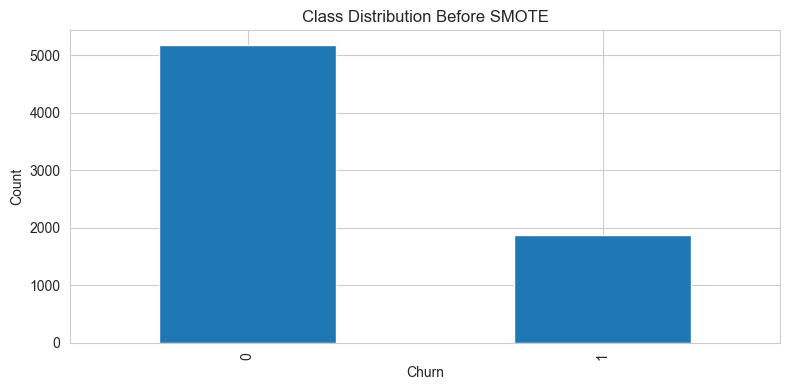

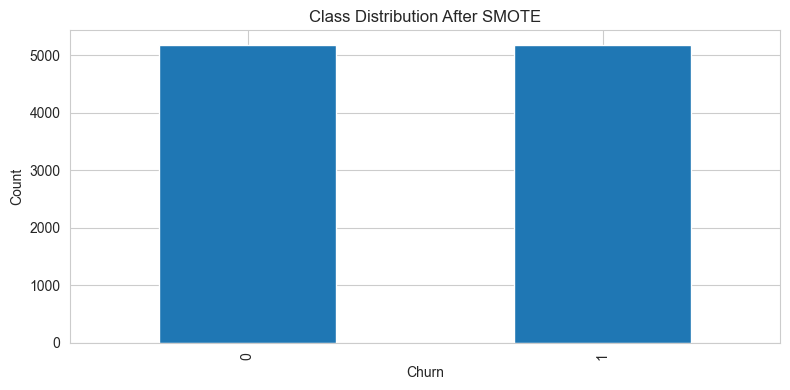

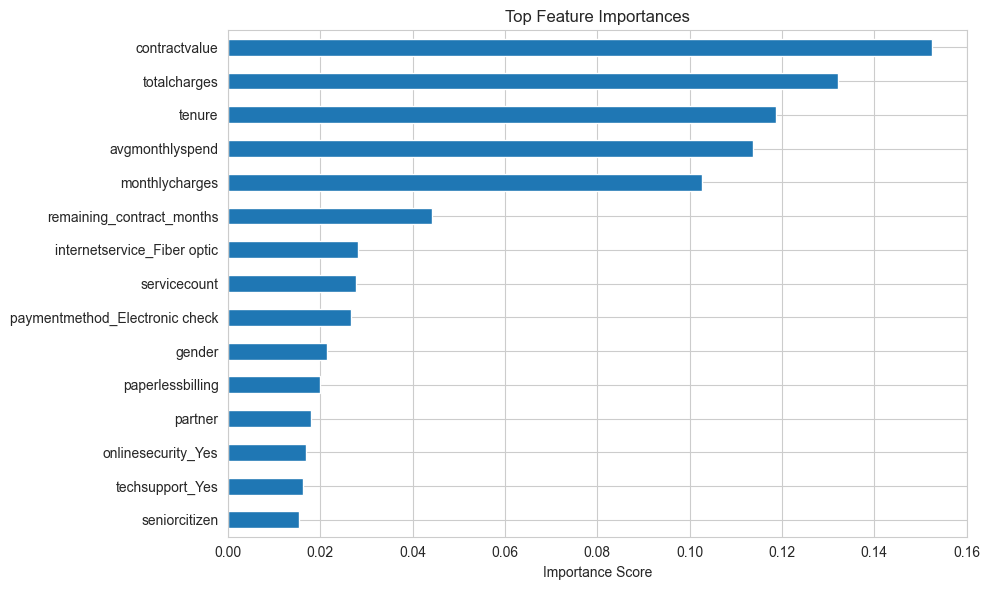

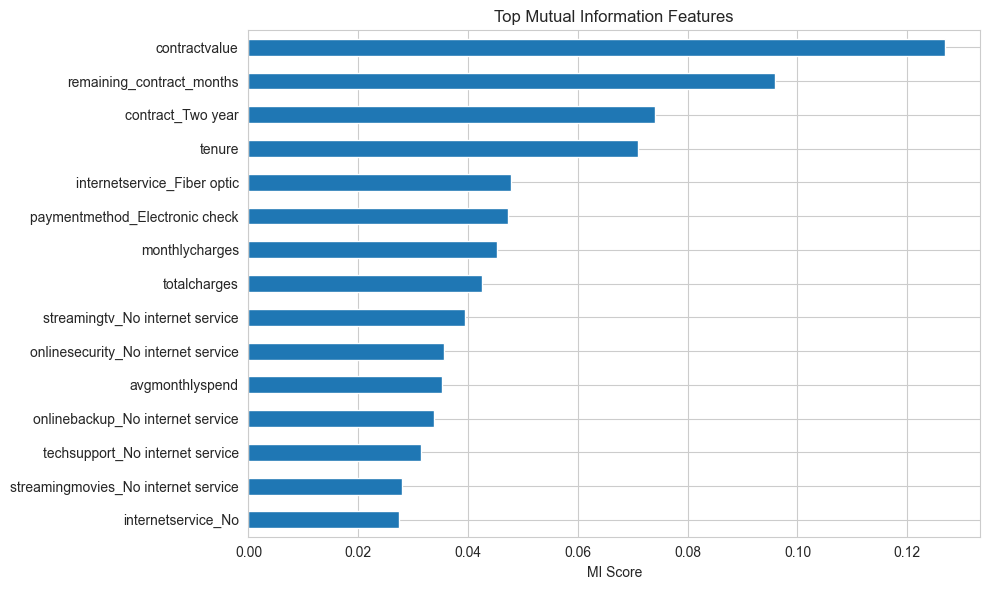

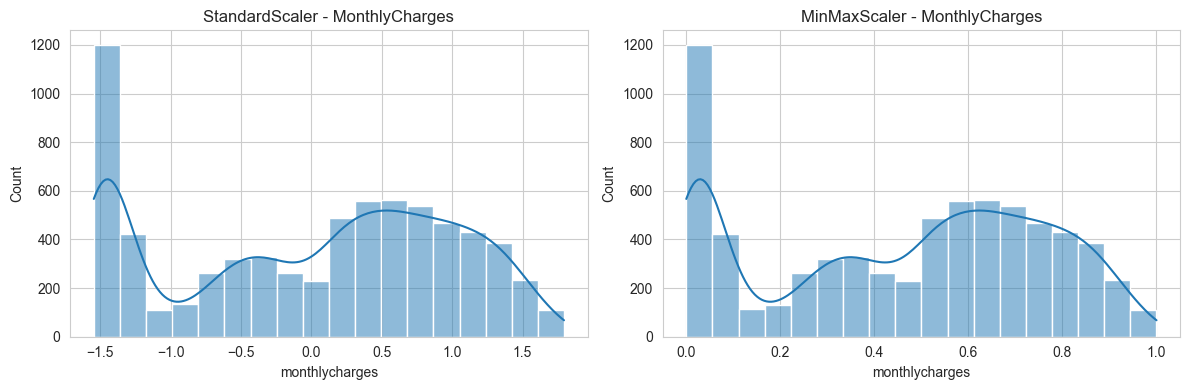

In [4]:
from src.utils import save_figure
# ============================================================
# Section 10 — Preprocessing Visualizations
# ============================================================

# -------------------------------
# 10A. Class Distribution Before SMOTE
# -------------------------------
plt.figure(figsize=(8, 4))
pd.Series(y).value_counts().plot(kind="bar")
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Churn")
plt.ylabel("Count")
save_figure("../reports/figures/class_distribution_before_smote.png")
plt.show()


# -------------------------------
# 10B. Class Distribution After SMOTE
# -------------------------------
plt.figure(figsize=(8, 4))
pd.Series(y_smote).value_counts().plot(kind="bar")
plt.title("Class Distribution After SMOTE")
plt.xlabel("Churn")
plt.ylabel("Count")
save_figure("../reports/figures/class_distribution_after_smote.png")
plt.show()


# -------------------------------
# 10C. Top Feature Importance Plot
# -------------------------------
fi = tree_feature_importance(X, y)

plt.figure(figsize=(10, 6))
fi.sort_values().plot(kind="barh")
plt.title("Top Feature Importances")
plt.xlabel("Importance Score")
save_figure("../reports/figures/feature_importance.png")
plt.show()


# -------------------------------
# 10D. Mutual Information Plot
# -------------------------------
mi = mutual_info_selection(X, y)

plt.figure(figsize=(10, 6))
mi.sort_values().plot(kind="barh")
plt.title("Top Mutual Information Features")
plt.xlabel("MI Score")
save_figure("../reports/figures/mutual_information.png")
plt.show()


# -------------------------------
# 10E. Scaling Comparison Plot
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_std["monthlycharges"], kde=True, ax=axes[0])
axes[0].set_title("StandardScaler - MonthlyCharges")

sns.histplot(df_mm["monthlycharges"], kde=True, ax=axes[1])
axes[1].set_title("MinMaxScaler - MonthlyCharges")

save_figure("../reports/figures/scaling_comparison.png")
plt.show()